In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("/mnt/lareaulab/reliscu/code")

from junction2psi import *

In [2]:
tables2_exons = pd.read_csv("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/differential_exons/irimia_2014/irimia_2014_tableS2_human_exons_lifted.csv")

In [52]:
all_exons = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_exon_PSI_corr.csv", index_col=0)

upreg_exons = pd.read_csv("data/ctype_exons/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_ascendingFalse.csv", index_col=0)
downreg_exons = pd.read_csv("data/ctype_exons/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_ascendingTrue.csv", index_col=0)

upreg_exons['Direction'] = "Upreg"
downreg_exons['Direction'] = "Downreg"

reg_exons = pd.concat([upreg_exons, downreg_exons], axis=0)
neuron_ctypes = ['All GABAergic', 'CGE Class', 'All Neuronal', 'Upper layer glutamatergic', 'Deep layer glutamatergic']
reg_exons = reg_exons[reg_exons['Cell_type'].isin(neuron_ctypes)]

reg_exons = reg_exons.reindex(all_exons.index)
reg_exons['Direction'] = reg_exons['Direction'].fillna("None")

In [53]:
def col2int(col):
    if pd.api.types.is_float_dtype(col) and (col.dropna() % 1 == 0).all():
        return col.astype("Int64")
    return col

tables2_exons = tables2_exons.apply(col2int, axis=0)

## Add coordinates to my exons

In [ ]:
intron_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/psix_annotation/intron_file.tab.gz"
intron_table = read_intron_file(intron_file)

intron_coords = pd.DataFrame(
    intron_table['intron'].str.split(":").str[1].str.split("-").to_list(),
    columns=["intron_first_base", "intron_last_base"],
    index=intron_table.index
)

intron_coords['exon'] = intron_coords.index.str.split("_").str[:3].str.join("_")
intron_coords = intron_coords[intron_coords['exon'].isin(reg_exons.index)]
intron_coords["intron_first_base"] = intron_coords["intron_first_base"].astype(int)
intron_coords["intron_last_base"] = intron_coords["intron_last_base"].astype(int)

exon_coords = intron_coords.groupby("exon").apply(lambda g: pd.Series({
    "exon_start": g.loc[g.index.str.contains("I1"), "intron_last_base"].values[0] + 1,
    "exon_end":   g.loc[g.index.str.contains("I2"), "intron_first_base"].values[0] - 1,
}))

In [23]:
reg_exons_coords = exon_coords.merge(reg_exons, left_index=True, right_index=True)

In [25]:
reg_exons_coords.value_counts("Direction")

Direction
Upreg      2859
Downreg    1207
Name: count, dtype: int64

## Plot exon length distro by regulation type (my hits)

In [29]:
reg_exons_coords['Length'] = reg_exons_coords['exon_end'] - reg_exons_coords['exon_start'] + 1

/tmp/ipykernel_1698479/2598080706.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = reg_exons_coords.groupby(['Direction', 'Length_bin']).size()


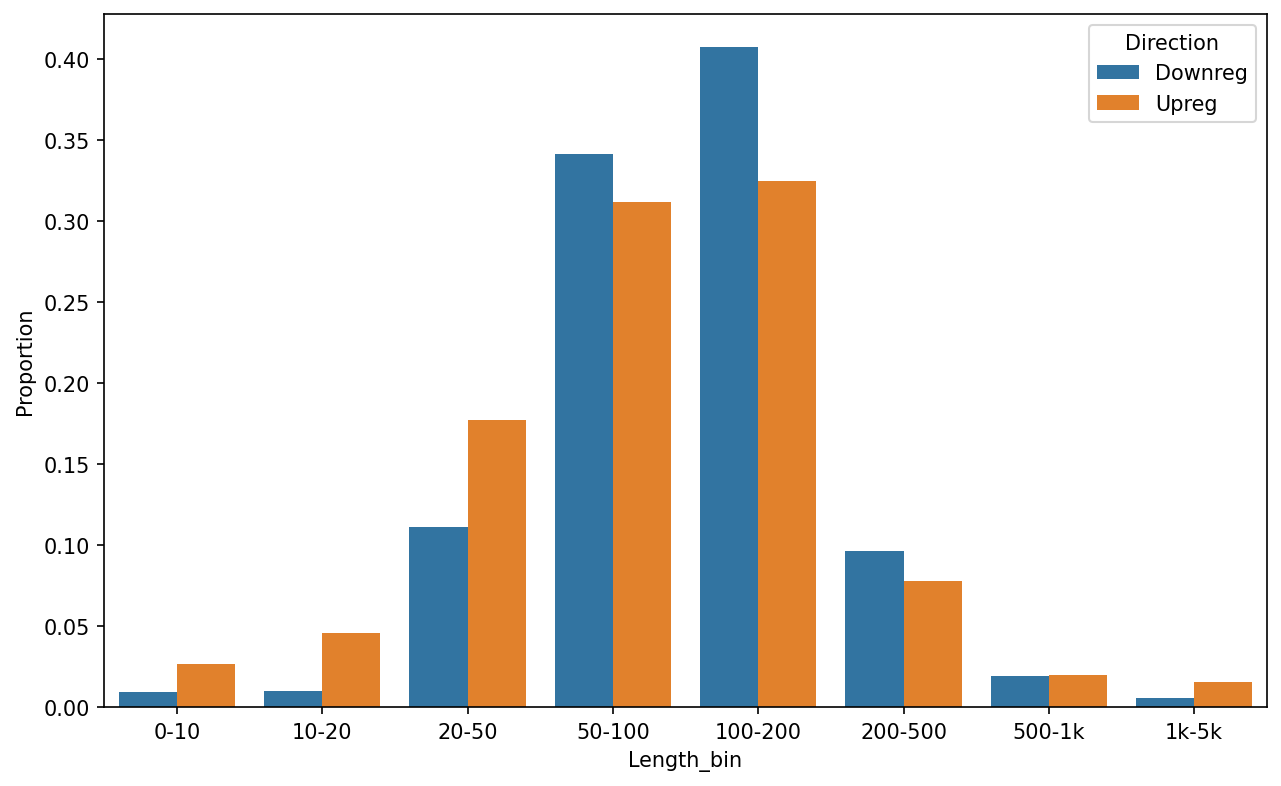

In [32]:
# Proportions within each Regulation group

reg_exons_coords['Length_bin'] = pd.cut(reg_exons_coords['Length'], 
                                                bins=[0, 10, 20, 50, 100, 200, 500, 1000, 5000],
                                                labels=['0-10', '10-20', '20-50', '50-100', '100-200', '200-500', '500-1k', '1k-5k'])

ct = reg_exons_coords.groupby(['Direction', 'Length_bin']).size()
props = ct.groupby(level=0).transform(lambda x: x / x.sum()).reset_index(name='Proportion')

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(data=props, x='Length_bin', y='Proportion', hue='Direction', ax=ax)
plt.show()

## Compare hits to previously reported exons

In [33]:
reg_exons_coords['My_coords'] = reg_exons_coords['exon_start'].astype(str) + "-" + reg_exons_coords['exon_end'].astype(str)
tables2_exons['Their_coords'] = tables2_exons['start'].astype(str) + "-" + tables2_exons['end'].astype(str)

In [34]:
overlap_exons = reg_exons_coords.merge(tables2_exons, left_on="My_coords", right_on="Their_coords")
overlap_exons.shape

(890, 22)

In [35]:
tables2_exons.shape

(2587, 9)

In [36]:
mask_upreg = overlap_exons['Direction'] == "Upreg"
overlap_exons[mask_upreg].value_counts("Neural Regulation")

Neural Regulation
NEURAL-UP      648
NEURAL-DOWN     18
Name: count, dtype: int64

In [37]:
mask_downreg = overlap_exons['Direction'] == "Downreg"
overlap_exons[mask_downreg].value_counts("Neural Regulation")

Neural Regulation
NEURAL-DOWN    207
NEURAL-UP       17
Name: count, dtype: int64

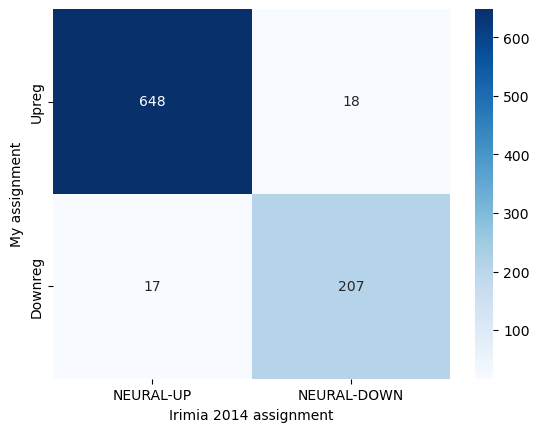

In [39]:
import seaborn as sns
import pandas as pd

contingency = pd.DataFrame(
    [[648, 18], [17, 207]],
    index=['Upreg', 'Downreg'],
    columns=['NEURAL-UP', 'NEURAL-DOWN']
)

sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.ylabel('My assignment')
plt.xlabel('Irimia 2014 assignment')
plt.show()

/tmp/ipykernel_1560421/3828180236.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = shared_exons_df_filt.groupby(['Regulation', 'Length_bin']).size()


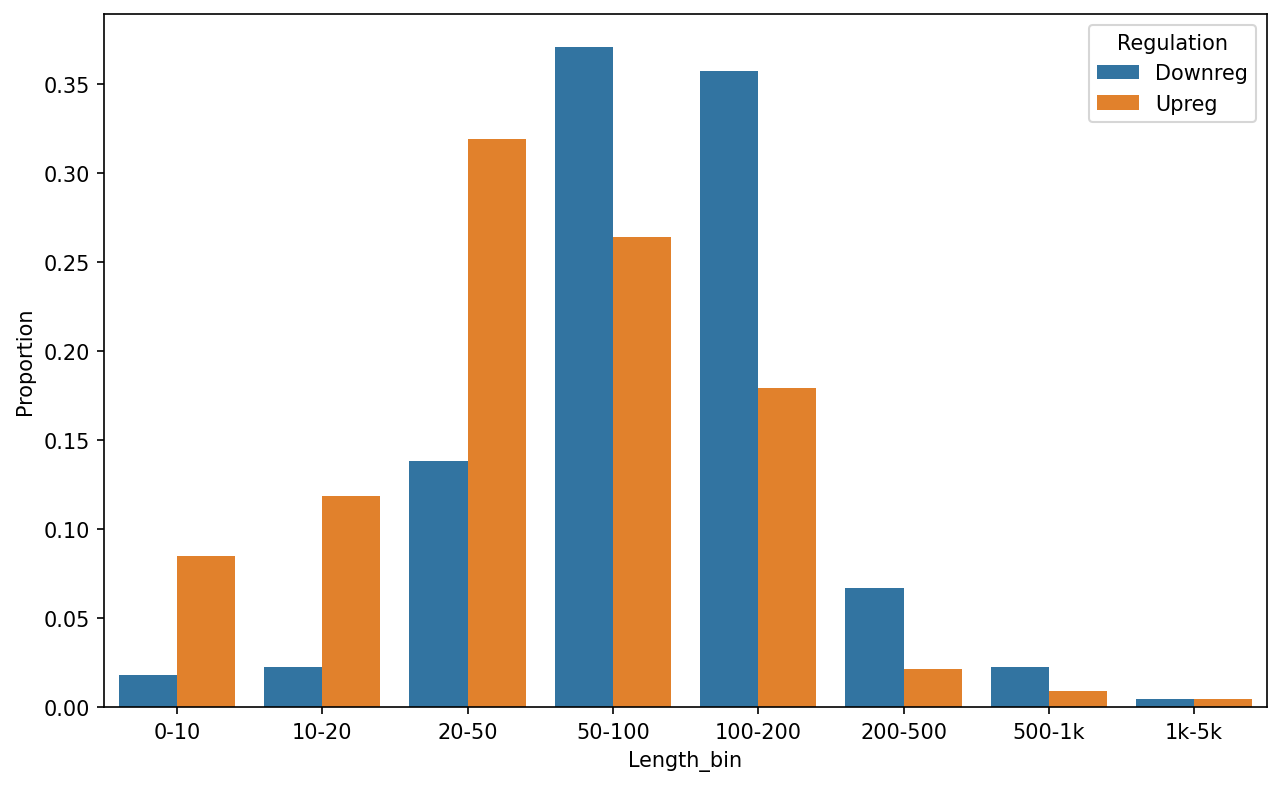

In [ ]:
overlap_exons['Length_bin'] = pd.cut(overlap_exons['Length'], 
                                     bins=[0, 10, 20, 50, 100, 200, 500, 1000, 5000],
                                     labels=['0-10', '10-20', '20-50', '50-100', '100-200', '200-500', '500-1k', '1k-5k'])

ct = overlap_exons.groupby(['Direction', 'Length_bin']).size()
props = ct.groupby(level=0).transform(lambda x: x / x.sum()).reset_index(name='Proportion')

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(data=props, x='Length_bin', y='Proportion', hue='Regulation', ax=ax)
plt.show()